# Instalações e importações

In [3]:
# Instalações
# Remova os comentários caso seja a primeira execução

# %pip install pandas
# %pip install matplotlib
%pip install tqdm
%pip install ipympl



Note: you may need to restart the kernel to use updated packages.
  Using cached contourpy-1.3.3-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 3.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 4.0 MB/s eta 0:00:00a 0:00:01
Using cached contourpy-1.3.3-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (362 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 3.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.9/914.9 kB 3.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 2.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 3.0 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [4]:
# Tenta abrir o visualizador interativo padrão do seu sistema operativo
%matplotlib auto
from pathlib import Path
import os
import glob
import pandas as pd
from typing import Any
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
from collections import Counter

Using matplotlib backend: module://matplotlib_inline.backend_inline


# Pre processamento

In [5]:
DATA_PATH = Path().cwd() / 'data'
DATASET_PATH  = DATA_PATH / 'CSE-CIC-IDS2018' 
SAMPLE_PCT = 20                # Substitua pela porcentagem desejada (ex: 10 para 10%)
RANDOM_SEED = 1
SKIP_IF_SAMPLE_ALREADY_EXSISTS = True
SKIP_IF_PREPROCESSED_EXISTS = True

SAMPLES_PATH = DATASET_PATH / 'samples'
PROCESSEDS_PATH = DATASET_PATH / 'processed'
os.makedirs(SAMPLES_PATH, exist_ok=True)
os.makedirs(PROCESSEDS_PATH, exist_ok=True)

processed_file_path = PROCESSEDS_PATH / f'data-{SAMPLE_PCT}_pct.csv'
if processed_file_path.is_file():
    df = pd.read_csv(processed_file_path)

### Cria samples dos arquivos originais que são muito grandes

In [6]:
if (not processed_file_path.is_file() or not SKIP_IF_PREPROCESSED_EXISTS):

    csv_files_paths = glob.glob(os.path.join(DATASET_PATH, f'*.csv'))

    if not csv_files_paths:
        print(f"Nenhum arquivo .csv encontrado no diretório: {DATASET_PATH}")
    else:
        print(f"Encontrados {len(csv_files_paths)} arquivos. Iniciando amostragem de {SAMPLE_PCT}%...\n")
        
        for file_path in csv_files_paths:
            filename = os.path.basename(file_path)
            filename_no_ext, ext = os.path.splitext(filename)
            
            new_filename = f"{filename_no_ext}-{SAMPLE_PCT}_pct{ext}"
            save_path = SAMPLES_PATH / new_filename
            
            if (save_path.is_file() and SKIP_IF_SAMPLE_ALREADY_EXSISTS):
                print(f"⏩ Arquivo {new_filename} já existente, processamento ignorado!")
                continue

            try:
                df = pd.read_csv(file_path)
                sample_df = df.sample(frac=SAMPLE_PCT / 100.0, random_state=RANDOM_SEED)
                sample_df.to_csv(save_path, index=False)
                
                print(f"✅ Salvo: {new_filename} | Linhas originais: {len(df)} -> Amostra: {len(sample_df)}")
                
            except Exception as e:
                print(f"❌ Erro ao processar o arquivo {filename}: {e}")

        print("\nProcessamento concluído com sucesso!")
else:
    print("⏩ Célula ignorada, dataset pre-processado encontrado")

Encontrados 10 arquivos. Iniciando amostragem de 20%...

✅ Salvo: 02-21-2018-20_pct.csv | Linhas originais: 1048575 -> Amostra: 209715
✅ Salvo: 02-15-2018-20_pct.csv | Linhas originais: 1048575 -> Amostra: 209715
✅ Salvo: 02-14-2018-20_pct.csv | Linhas originais: 1048575 -> Amostra: 209715


/tmp/ipykernel_12181/2929764875.py:22: DtypeWarning: Columns (0: Dst Port, 1: Protocol, 2: Flow Duration, 3: Tot Fwd Pkts, 4: Tot Bwd Pkts, 5: TotLen Fwd Pkts, 6: TotLen Bwd Pkts, 7: Fwd Pkt Len Max, 8: Fwd Pkt Len Min, 9: Fwd Pkt Len Mean, 10: Fwd Pkt Len Std, 11: Bwd Pkt Len Max, 12: Bwd Pkt Len Min, 13: Bwd Pkt Len Mean, 14: Bwd Pkt Len Std, 15: Flow Byts/s, 16: Flow Pkts/s, 17: Flow IAT Mean, 18: Flow IAT Std, 19: Flow IAT Max, 20: Flow IAT Min, 21: Fwd IAT Tot, 22: Fwd IAT Mean, 23: Fwd IAT Std, 24: Fwd IAT Max, 25: Fwd IAT Min, 26: Bwd IAT Tot, 27: Bwd IAT Mean, 28: Bwd IAT Std, 29: Bwd IAT Max, 30: Bwd IAT Min, 31: Fwd PSH Flags, 32: Bwd PSH Flags, 33: Fwd URG Flags, 34: Bwd URG Flags, 35: Fwd Header Len, 36: Bwd Header Len, 37: Fwd Pkts/s, 38: Bwd Pkts/s, 39: Pkt Len Min, 40: Pkt Len Max, 41: Pkt Len Mean, 42: Pkt Len Std, 43: Pkt Len Var, 44: FIN Flag Cnt, 45: SYN Flag Cnt, 46: RST Flag Cnt, 47: PSH Flag Cnt, 48: ACK Flag Cnt, 49: URG Flag Cnt, 50: CWE Flag Count, 51: ECE Flag

✅ Salvo: 03-01-2018-20_pct.csv | Linhas originais: 331125 -> Amostra: 66225
✅ Salvo: 03-02-2018-20_pct.csv | Linhas originais: 1048575 -> Amostra: 209715
✅ Salvo: 02-22-2018-20_pct.csv | Linhas originais: 1048575 -> Amostra: 209715


/tmp/ipykernel_12181/2929764875.py:22: DtypeWarning: Columns (0: Dst Port, 1: Protocol, 2: Flow Duration, 3: Tot Fwd Pkts, 4: Tot Bwd Pkts, 5: TotLen Fwd Pkts, 6: TotLen Bwd Pkts, 7: Fwd Pkt Len Max, 8: Fwd Pkt Len Min, 9: Fwd Pkt Len Mean, 10: Fwd Pkt Len Std, 11: Bwd Pkt Len Max, 12: Bwd Pkt Len Min, 13: Bwd Pkt Len Mean, 14: Bwd Pkt Len Std, 15: Flow Byts/s, 16: Flow Pkts/s, 17: Flow IAT Mean, 18: Flow IAT Std, 19: Flow IAT Max, 20: Flow IAT Min, 21: Fwd IAT Tot, 22: Fwd IAT Mean, 23: Fwd IAT Std, 24: Fwd IAT Max, 25: Fwd IAT Min, 26: Bwd IAT Tot, 27: Bwd IAT Mean, 28: Bwd IAT Std, 29: Bwd IAT Max, 30: Bwd IAT Min, 31: Fwd PSH Flags, 32: Bwd PSH Flags, 33: Fwd URG Flags, 34: Bwd URG Flags, 35: Fwd Header Len, 36: Bwd Header Len, 37: Fwd Pkts/s, 38: Bwd Pkts/s, 39: Pkt Len Min, 40: Pkt Len Max, 41: Pkt Len Mean, 42: Pkt Len Std, 43: Pkt Len Var, 44: FIN Flag Cnt, 45: SYN Flag Cnt, 46: RST Flag Cnt, 47: PSH Flag Cnt, 48: ACK Flag Cnt, 49: URG Flag Cnt, 50: CWE Flag Count, 51: ECE Flag

✅ Salvo: 02-16-2018-20_pct.csv | Linhas originais: 1048575 -> Amostra: 209715
✅ Salvo: 02-20-2018-20_pct.csv | Linhas originais: 7948748 -> Amostra: 1589750
✅ Salvo: 02-23-2018-20_pct.csv | Linhas originais: 1048575 -> Amostra: 209715


/tmp/ipykernel_12181/2929764875.py:22: DtypeWarning: Columns (0: Dst Port, 1: Protocol, 2: Flow Duration, 3: Tot Fwd Pkts, 4: Tot Bwd Pkts, 5: TotLen Fwd Pkts, 6: TotLen Bwd Pkts, 7: Fwd Pkt Len Max, 8: Fwd Pkt Len Min, 9: Fwd Pkt Len Mean, 10: Fwd Pkt Len Std, 11: Bwd Pkt Len Max, 12: Bwd Pkt Len Min, 13: Bwd Pkt Len Mean, 14: Bwd Pkt Len Std, 15: Flow Byts/s, 16: Flow Pkts/s, 17: Flow IAT Mean, 18: Flow IAT Std, 19: Flow IAT Max, 20: Flow IAT Min, 21: Fwd IAT Tot, 22: Fwd IAT Mean, 23: Fwd IAT Std, 24: Fwd IAT Max, 25: Fwd IAT Min, 26: Bwd IAT Tot, 27: Bwd IAT Mean, 28: Bwd IAT Std, 29: Bwd IAT Max, 30: Bwd IAT Min, 31: Fwd PSH Flags, 32: Bwd PSH Flags, 33: Fwd URG Flags, 34: Bwd URG Flags, 35: Fwd Header Len, 36: Bwd Header Len, 37: Fwd Pkts/s, 38: Bwd Pkts/s, 39: Pkt Len Min, 40: Pkt Len Max, 41: Pkt Len Mean, 42: Pkt Len Std, 43: Pkt Len Var, 44: FIN Flag Cnt, 45: SYN Flag Cnt, 46: RST Flag Cnt, 47: PSH Flag Cnt, 48: ACK Flag Cnt, 49: URG Flag Cnt, 50: CWE Flag Count, 51: ECE Flag

✅ Salvo: 02-28-2018-20_pct.csv | Linhas originais: 613104 -> Amostra: 122621

Processamento concluído com sucesso!


### Unifica todas as amostras em um único dataframe

In [7]:
if (not processed_file_path.is_file() or not SKIP_IF_PREPROCESSED_EXISTS):
    sampled_csv_files = glob.glob(os.path.join(SAMPLES_PATH, f'*-{SAMPLE_PCT}_pct.csv'))

    # Identificando as colunas padrões de todos os arquivos
    base_columns = None
    for file in sampled_csv_files:
        # Lê apenas a primeira linha para ser ultra rápido e checar o número de colunas
        df_temp = pd.read_csv(file, nrows=0)
        if len(df_temp.columns) == 80:
            base_columns = list(df_temp.columns)
            print(f"📌 Padrão de 80 colunas encontrado e definido a partir de: {os.path.basename(file)}")
            break

    # Validação caso nenhum arquivo tenha 80 colunas
    if base_columns is None:
        raise ValueError("❌ Nenhum arquivo com exatamente 80 colunas foi encontrado para servir de base.")

    # Lê, filtra colunas e unifica os datasets
    df_list: list[pd.DataFrame] = []

    print("\nIniciando a leitura e unificação dos arquivos...")
    for file in sampled_csv_files:
        filename = os.path.basename(file)
        try:
            # Lê o arquivo completo
            df = pd.read_csv(file)
            
            # Se o arquivo tiver colunas a mais (ex: 84 colunas), filtramos apenas as 80 da base
            # Se tiver exatamente 80, ele mantém igual.
            filtered_df: pd.DataFrame = df[base_columns]
            df_list.append(filtered_df)
            print(f"   ✅ {filename} processado ({len(df.columns)} colunas -> reduzido para 80)")
            
        except KeyError:
            print(f"   ⚠️ Avisando: O arquivo {filename} não possui todas as colunas necessárias da base e foi ignorado.")
        except Exception as e:
            print(f"   ❌ Erro ao ler {filename}: {e}")

    # Consolida tudo em um único DataFrame
    df = pd.concat(df_list, ignore_index=True)

    print("\nConvertendo a coluna 'Timestamp' para formato Epoch...")

    # Remove linhas onde o valor é literalmente a palavra 'Timestamp' (cabeçalhos no meio do dado)
    df = df[df['Timestamp'] != 'Timestamp'].copy()

    # 1. Transforma o texto em um objeto de data/hora do pandas (datetime)
    df['Timestamp_dt'] = pd.to_datetime(df['Timestamp'], format='%d/%m/%Y %H:%M:%S')

    # 2. Converte o datetime para nanosegundos desde a epoch, e divide por 10**9 para virar segundos (Timestamp Unix)
    # Convertemos para 'int64' para remover as casas decimais
    df['Timestamp'] = (df['Timestamp_dt'].astype('int64') // 10**9)

    # 3. Remove a coluna temporária de datetime que criamos para o cálculo
    df = df.drop(columns=['Timestamp_dt'])

    # 4. Ordena o dataframe de forma cronológica (do mais antigo para o mais recente)
    df = df.sort_values(by='Timestamp').reset_index(drop=True)

    df.to_csv(processed_file_path, index=False)
    print(f"✨ Concluído! Dataset final gerado com {df.shape[0]} linhas e {df.shape[1]} colunas.")
else: 
    print("⏩ Célula ignorada, dataset pre-processado encontrado")
df.head(5)

📌 Padrão de 80 colunas encontrado e definido a partir de: 03-01-2018-20_pct.csv

Iniciando a leitura e unificação dos arquivos...


/tmp/ipykernel_12181/2349533054.py:26: DtypeWarning: Columns (0: Dst Port, 1: Protocol, 2: Flow Duration, 3: Tot Fwd Pkts, 4: Tot Bwd Pkts, 5: TotLen Fwd Pkts, 6: TotLen Bwd Pkts, 7: Fwd Pkt Len Max, 8: Fwd Pkt Len Min, 9: Fwd Pkt Len Mean, 10: Fwd Pkt Len Std, 11: Bwd Pkt Len Max, 12: Bwd Pkt Len Min, 13: Bwd Pkt Len Mean, 14: Bwd Pkt Len Std, 15: Flow Byts/s, 16: Flow Pkts/s, 17: Flow IAT Mean, 18: Flow IAT Std, 19: Flow IAT Max, 20: Flow IAT Min, 21: Fwd IAT Tot, 22: Fwd IAT Mean, 23: Fwd IAT Std, 24: Fwd IAT Max, 25: Fwd IAT Min, 26: Bwd IAT Tot, 27: Bwd IAT Mean, 28: Bwd IAT Std, 29: Bwd IAT Max, 30: Bwd IAT Min, 31: Fwd PSH Flags, 32: Bwd PSH Flags, 33: Fwd URG Flags, 34: Bwd URG Flags, 35: Fwd Header Len, 36: Bwd Header Len, 37: Fwd Pkts/s, 38: Bwd Pkts/s, 39: Pkt Len Min, 40: Pkt Len Max, 41: Pkt Len Mean, 42: Pkt Len Std, 43: Pkt Len Var, 44: FIN Flag Cnt, 45: SYN Flag Cnt, 46: RST Flag Cnt, 47: PSH Flag Cnt, 48: ACK Flag Cnt, 49: URG Flag Cnt, 50: CWE Flag Count, 51: ECE Flag

   ✅ 03-01-2018-20_pct.csv processado (80 colunas -> reduzido para 80)
   ✅ 02-23-2018-20_pct.csv processado (80 colunas -> reduzido para 80)
   ✅ 02-20-2018-20_pct.csv processado (84 colunas -> reduzido para 80)
   ✅ 02-14-2018-20_pct.csv processado (80 colunas -> reduzido para 80)
   ✅ 02-21-2018-20_pct.csv processado (80 colunas -> reduzido para 80)
   ✅ 03-02-2018-20_pct.csv processado (80 colunas -> reduzido para 80)
   ✅ 02-22-2018-20_pct.csv processado (80 colunas -> reduzido para 80)
   ✅ 02-28-2018-20_pct.csv processado (80 colunas -> reduzido para 80)
   ✅ 02-16-2018-20_pct.csv processado (80 colunas -> reduzido para 80)
   ✅ 02-15-2018-20_pct.csv processado (80 colunas -> reduzido para 80)

Convertendo a coluna 'Timestamp' para formato Epoch...
✨ Concluído! Dataset final gerado com 3246592 linhas e 80 colunas.


,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,0,788,-188505000000,9,0,0,0,0,0,...,0,0.0,0.0,0,0,197474750000.0,141251680160.803986,324807000000,21756000000,Benign
1,0,0,954,-699056000000,38,0,0,0,0,0,...,0,0.0,0.0,0,0,259393421052.631989,176008086248.683014,606052000000,51960000000,Benign
2,0,0,976,-919011000000,81,0,0,0,0,0,...,0,0.0,0.0,0,0,284112452380.952026,193152417061.481995,754847000000,12603000000,Benign
3,443,6,1518570,116184697,21,22,369,8563,201,0,...,20,43708.666667,39607.73218,169480,32181,9638347.916667,1298567.644125,10014326,5514855,Benign
4,443,6,1518570,4192145,9,24,1349,5911,485,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign


#### Limpeza dos dados

In [8]:
before_lines = df.shape[0]
df = df.dropna()
after_lines = df.shape[0]
print(f"🗑️ Linhas com valores nulos removidas: {before_lines - after_lines}")

before_cols = df.shape[1]
df = df.loc[:, df.nunique() > 1]
after_cols = df.shape[1]

print(f"🗑️ Colunas constantes removidas: {before_cols - after_cols}")

print(f"\n✨ Limpeza concluída! Dataset atualizado com {df.shape[0]} linhas e {df.shape[1]} colunas.")

df.head(5)

🗑️ Linhas com valores nulos removidas: 11911
🗑️ Colunas constantes removidas: 0

✨ Limpeza concluída! Dataset atualizado com 3234681 linhas e 80 colunas.


,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,0,788,-188505000000,9,0,0,0,0,0,...,0,0.0,0.0,0,0,197474750000.0,141251680160.803986,324807000000,21756000000,Benign
1,0,0,954,-699056000000,38,0,0,0,0,0,...,0,0.0,0.0,0,0,259393421052.631989,176008086248.683014,606052000000,51960000000,Benign
2,0,0,976,-919011000000,81,0,0,0,0,0,...,0,0.0,0.0,0,0,284112452380.952026,193152417061.481995,754847000000,12603000000,Benign
3,443,6,1518570,116184697,21,22,369,8563,201,0,...,20,43708.666667,39607.73218,169480,32181,9638347.916667,1298567.644125,10014326,5514855,Benign
4,443,6,1518570,4192145,9,24,1349,5911,485,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign


In [9]:
numerical_cols = df.select_dtypes(include='number').columns.tolist()
categorical_cols = df.select_dtypes(exclude='number').columns.tolist()

print(f"📊 COLUNAS NUMÉRICAS ({len(numerical_cols)} no total):")
if numerical_cols:
    print(', '.join(numerical_cols))
else:
    print("Nenhuma coluna numérica encontrada.")

print("\n" + "-"*80 + "\n")

print(f"🔤 COLUNAS CATEGÓRICAS / TEXTUAIS ({len(categorical_cols)} no total):")
if categorical_cols:
    print(', '.join(categorical_cols))
else:
    print("Nenhuma coluna categórica ou textual encontrada.")

📊 COLUNAS NUMÉRICAS (1 no total):
Timestamp

--------------------------------------------------------------------------------

🔤 COLUNAS CATEGÓRICAS / TEXTUAIS (79 no total):
Dst Port, Protocol, Flow Duration, Tot Fwd Pkts, Tot Bwd Pkts, TotLen Fwd Pkts, TotLen Bwd Pkts, Fwd Pkt Len Max, Fwd Pkt Len Min, Fwd Pkt Len Mean, Fwd Pkt Len Std, Bwd Pkt Len Max, Bwd Pkt Len Min, Bwd Pkt Len Mean, Bwd Pkt Len Std, Flow Byts/s, Flow Pkts/s, Flow IAT Mean, Flow IAT Std, Flow IAT Max, Flow IAT Min, Fwd IAT Tot, Fwd IAT Mean, Fwd IAT Std, Fwd IAT Max, Fwd IAT Min, Bwd IAT Tot, Bwd IAT Mean, Bwd IAT Std, Bwd IAT Max, Bwd IAT Min, Fwd PSH Flags, Bwd PSH Flags, Fwd URG Flags, Bwd URG Flags, Fwd Header Len, Bwd Header Len, Fwd Pkts/s, Bwd Pkts/s, Pkt Len Min, Pkt Len Max, Pkt Len Mean, Pkt Len Std, Pkt Len Var, FIN Flag Cnt, SYN Flag Cnt, RST Flag Cnt, PSH Flag Cnt, ACK Flag Cnt, URG Flag Cnt, CWE Flag Count, ECE Flag Cnt, Down/Up Ratio, Pkt Size Avg, Fwd Seg Size Avg, Bwd Seg Size Avg, Fwd Byts/b Avg

### Correção de Tipos: Convertendo Falsas Numéricas em Categóricas

In [10]:
print("Corrigindo os tipos de dados das colunas...\n")

# Lista das colunas que o Pandas acha que são números, mas na verdade são categorias nominais
false_numerical_cols = ['Dst Port', 'Protocol']

# Filtramos apenas as que realmente estão no dataframe (caso alguma tenha sido removida nas etapas de limpeza)
cols_to_convert = [col for col in false_numerical_cols if col in df.columns]

if cols_to_convert:
    for col in cols_to_convert:
        df[col] = df[col].astype('category')
        print(f"🔄 Coluna '{col}' convertida com sucesso para o tipo 'category'.")
else:
    print("Nenhuma das colunas falsas numéricas foi encontrada no DataFrame atual.")

# Exibe o tipo de dado atualizado apenas das colunas que modificamos, além do nosso Timestamp
check_cols = cols_to_convert + (['Timestamp'] if 'Timestamp' in df.columns else [])
print("\nTipos de dados atualizados para conferência:")
print(df[check_cols].dtypes)

Corrigindo os tipos de dados das colunas...

🔄 Coluna 'Dst Port' convertida com sucesso para o tipo 'category'.
🔄 Coluna 'Protocol' convertida com sucesso para o tipo 'category'.

Tipos de dados atualizados para conferência:
Dst Port     category
Protocol     category
Timestamp       int64
dtype: object


# Algoritmo Bayesiano

In [11]:
work_columns = ['Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'Label']
work_df = df[work_columns]
knowledge_df = work_df.sample(frac=0.999, random_state=RANDOM_SEED)
test_df = work_df.drop(knowledge_df.index)
possible_labels = work_df['Label'].unique()

with_exact_correspondence = 0
correct_inferences = 0
correct_inferences_with_more_of_50_pct = 0

for i,item in tqdm(test_df.iterrows(), total=test_df.shape[0], desc="Processando linhas"):
    equal_df = knowledge_df[(knowledge_df['Dst Port'] == item['Dst Port']) & 
                            (knowledge_df['Protocol'] == item['Protocol']) &
                            (knowledge_df['Flow Duration'] == item['Flow Duration'])&
                            (knowledge_df['Tot Fwd Pkts'] == item['Tot Fwd Pkts']) &
                            (knowledge_df['Tot Bwd Pkts'] == item['Tot Bwd Pkts'])]
    
    if (equal_df.shape[0] == 0):
        # print('Sem correspondência exata!')
        continue
    with_exact_correspondence += 1

    benign_df = equal_df[(equal_df['Label'] == 'Benign')]
    benign_ratio = benign_df.shape[0] / equal_df.shape[0]

    greater_ratio = (0, '')
    print_str = ''
    for possible_label in possible_labels:
        with_label_df = equal_df[equal_df['Label'] == possible_label]
        with_label_ratio = with_label_df.shape[0]/equal_df.shape[0]
        if (with_label_ratio > 0): print_str += f'{possible_label}: {with_label_ratio * 100}%, '

        if (greater_ratio is None or with_label_ratio > greater_ratio[0]):
            greater_ratio = (with_label_ratio, possible_label)

    if (greater_ratio[1] == item['Label']):
        correct_inferences +=1
        if (greater_ratio[0] > 0.5):
            correct_inferences_with_more_of_50_pct += 1

    if print_str != '' and benign_ratio <= 0.5:
        # print(print_str)
        pass

print(f'Total de itens testados: {test_df.shape[0]}, total com correspondencia exata: {with_exact_correspondence} | {with_exact_correspondence / test_df.shape[0] * 100:.4f}%')
print(f'Total de inferencias corretas (maior proporção como a certa): {correct_inferences}/{with_exact_correspondence} ({correct_inferences/with_exact_correspondence * 100:.4f}%)')
print(f'Total de inferencias corretas com maioria de probabilidade: {correct_inferences_with_more_of_50_pct}/{with_exact_correspondence} ({correct_inferences_with_more_of_50_pct/with_exact_correspondence * 100:.4f}%)')



Processando linhas:   3%|▎         | 94/3235 [01:02<34:52,  1.50it/s]


KeyboardInterrupt: 

## Algoritmo Naive Bayes

In [ ]:
features = ['Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts']
target = 'Label'



work_df = df[features + [target]]

work_df.loc[(work_df[target] == 'DDOS attack-LOIC-UDP') |
            (work_df[target] == 'DoS attacks-Slowloris') |
            (work_df[target] == 'DoS attacks-GoldenEye') |
            (work_df[target] == 'DoS attacks-SlowHTTPTest') |
            (work_df[target] == 'DoS attacks-Hulk') |
            (work_df[target] == 'DDoS attacks-LOIC-HTTP') |
            (work_df[target] == 'DDOS attack-HOIC'), target] = 'DDoS'

work_df.loc[(work_df[target] == 'Brute Force -XSS') |
            (work_df[target] == 'Brute Force -Web') | 
            (work_df[target] == 'SSH-Bruteforce') | 
            (work_df[target] == 'FTP-BruteForce'), target] = 'BruteForce'

work_df.loc[(work_df[target] == 'Bot') |
            (work_df[target] == 'Infilteration') | 
            (work_df[target] == 'SQL Injection'), target] = 'Other'

possible_labels = work_df[target].unique()

# Vamos fazer undersampling no work_df para termos a mesma quantidade de dados para cada label diferente
min_class_size = work_df[target].value_counts().min()
print(work_df[target].value_counts())
work_df = work_df.groupby(target).sample(n=min_class_size, random_state=RANDOM_SEED)
work_df = work_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
print(work_df[target].value_counts())

work_df.to_csv('./work_dataframe.csv', index=False)



knowledge_df = work_df.sample(frac=0.995, random_state=RANDOM_SEED)
raw_test_df = work_df.drop(knowledge_df.index)

X_test = raw_test_df[features]
y_test = raw_test_df[target]

total_knowledge_rows = knowledge_df.shape[0]

model_predictions = []
labels_data: dict[str, dict[str, Any]] = {}

for label in possible_labels:
    label_df = knowledge_df[knowledge_df[target] == label]
    label_prob = label_df.shape[0] / total_knowledge_rows

    labels_data[label] = {
        'df': label_df,
        'prob': label_prob
    }
        
for i, item in tqdm(X_test.iterrows(), total=X_test.shape[0], desc="Processando linhas"):
    best_label = None
    max_prob = -1
    label_found_probs = {}
    
    for label in (possible_labels):
        label_df: pd.DataFrame = labels_data[label]['df']
        current_prob: float = labels_data[label]['prob']

        for col in features:
            # Conta quantas vezes o valor da feature do teste apareceu dentro deste Label
            feature_match_df = label_df[label_df[col] == item[col]]
            
            # feature_prob = (Linhas que bateram a feature) / (Total de linhas deste Label)
            feature_prob = feature_match_df.shape[0] / label_df.shape[0]
            
            # Suavização: Se não encontrou nenhuma correspondência, aplica um valor mínimo
            if feature_prob == 0:
                feature_prob = 1e-6
                
            current_prob *= feature_prob
            
        label_found_probs[label] = current_prob
        if current_prob > max_prob:
            max_prob = current_prob
            best_label = label
    
    model_predictions.append((best_label, label_found_probs))

results_df = pd.DataFrame({
    'Model_Prediction': map(lambda x: x[0], model_predictions),
    'Model_Prediction_probs': map(lambda x: x[1], model_predictions),
    'Actual_Label': y_test.values
})

correct_predictions = (results_df['Model_Prediction'] == results_df['Actual_Label']).sum()
total_tested = len(results_df)
accuracy = (correct_predictions / total_tested) * 100

print(f'\nTotal de pacotes testados: {total_tested}')
print(f'Total de acertos: {correct_predictions}')
print(f'Acurácia final: {accuracy:.4f}%')


Label
Benign        2684084
DDoS           384576
Other           89413
BruteForce      76608
Name: count, dtype: int64
Label
Other         76608
DDoS          76608
Benign        76608
BruteForce    76608
Name: count, dtype: int64


Processando linhas: 100%|██████████| 1532/1532 [00:28<00:00, 53.32it/s]


Total de pacotes testados: 1532
Total de acertos: 1331
Acurácia final: 86.8799%


In [ ]:
def formatar_probabilidades(prob_dict: dict[str, float]) -> dict[str, str]:
    # 1. Calcula a soma total de todas as probabilidades
    soma_total = sum(prob_dict.values())
    
    dict_formatado = {}
    
    # Prevenção contra underflow (se todos os valores forem zero)
    if soma_total == 0:
        return {label: "0.00%" for label in prob_dict}

    # 2. Normaliza e formata para porcentagem
    for label, prob in prob_dict.items():
        porcentagem = (prob / soma_total) * 100
        
        # Formata a string para ter 2 casas decimais e o símbolo de %
        # Se quiser mais precisão, mude .2f para .4f
        dict_formatado[label] = f"{porcentagem:.2f}%"
        
    return dict_formatado

results_df['Model_Prediction_probs'] = results_df['Model_Prediction_probs'].apply(formatar_probabilidades)

results_df

,Model_Prediction,Model_Prediction_probs,Actual_Label
0,Benign,"{'Benign': '97.64%', 'BruteForce': '0.00%', 'D...",Other
1,DDoS,"{'Benign': '0.19%', 'BruteForce': '0.00%', 'DD...",DDoS
2,BruteForce,"{'Benign': '0.00%', 'BruteForce': '100.00%', '...",BruteForce
3,DDoS,"{'Benign': '0.07%', 'BruteForce': '0.00%', 'DD...",DDoS
4,DDoS,"{'Benign': '0.04%', 'BruteForce': '0.00%', 'DD...",DDoS
...,...,...,...
1527,BruteForce,"{'Benign': '0.00%', 'BruteForce': '99.98%', 'D...",BruteForce
1528,BruteForce,"{'Benign': '0.00%', 'BruteForce': '100.00%', '...",BruteForce
1529,Benign,"{'Benign': '93.46%', 'BruteForce': '0.00%', 'D...",Benign
1530,Other,"{'Benign': '0.01%', 'BruteForce': '0.00%', 'DD...",Other


Label
Other         0.25
DDoS          0.25
Benign        0.25
BruteForce    0.25
Name: proportion, dtype: float64


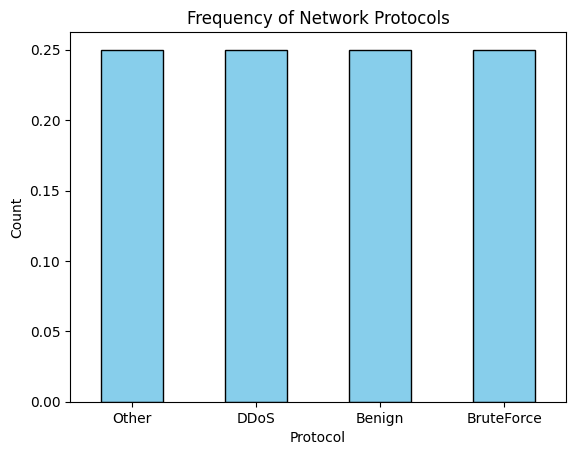

In [ ]:
values_count = work_df['Label'].value_counts(normalize=True)
print(values_count)
values_count.plot(
    kind='bar', 
    title='Frequency of Network Protocols',
    xlabel='Protocol',
    ylabel='Count',
    color='skyblue',
    edgecolor='black'
)

# 3. Show the plot
plt.xticks(rotation=0) # Keeps the labels horizontal
plt.show()

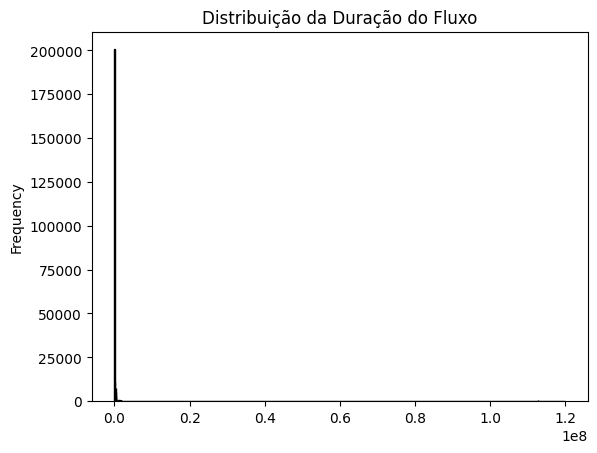

In [ ]:
work_df['Flow Duration'].plot(
    kind='hist',
    bins=5000, # Número de "fatias" do gráfico
    title='Distribuição da Duração do Fluxo',
    color='steelblue',
    edgecolor='black'
)

plt.show()

## KNN

In [ ]:
features = ['Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts']
target = 'Label'


work_df = df[features + [target]].copy()

work_df.loc[(work_df[target] == 'DDOS attack-LOIC-UDP') |
            (work_df[target] == 'DoS attacks-Slowloris') |
            (work_df[target] == 'DoS attacks-GoldenEye') |
            (work_df[target] == 'DoS attacks-SlowHTTPTest') |
            (work_df[target] == 'DoS attacks-Hulk') |
            (work_df[target] == 'DDoS attacks-LOIC-HTTP') |
            (work_df[target] == 'DDOS attack-HOIC'), target] = 'DDoS'

work_df.loc[(work_df[target] == 'Brute Force -XSS') |
            (work_df[target] == 'Brute Force -Web') | 
            (work_df[target] == 'SSH-Bruteforce') | 
            (work_df[target] == 'FTP-BruteForce'), target] = 'BruteForce'

work_df.loc[(work_df[target] == 'Bot') |
            (work_df[target] == 'Infilteration') | 
            (work_df[target] == 'SQL Injection'), target] = 'Other'

possible_labels = work_df[target].unique()

min_class_size = work_df[target].value_counts().min()
print( work_df[target].value_counts())

work_df = work_df.groupby(target).sample(n=min_class_size, random_state=RANDOM_SEED)
work_df = work_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

print(work_df[target].value_counts())

for col in features:
    work_df[col] = pd.to_numeric(work_df[col], errors='coerce')

work_df[features] = work_df[features].fillna(0)

features_min = work_df[features].min()
features_max = work_df[features].max()

work_df_norm = work_df.copy()

diff = features_max - features_min
diff = diff.replace(0, 1)

work_df_norm[features] = (work_df[features] - features_min) / diff

knowledge_df = work_df_norm.sample(frac=0.995, random_state=RANDOM_SEED)
raw_test_df = work_df_norm.drop(knowledge_df.index)

X_test = raw_test_df[features].values
y_test = raw_test_df[target].values

X_train = knowledge_df[features].values
y_train = knowledge_df[target].values

K = 5 
model_predictions = []

for i in tqdm(range(len(X_test)), desc="Analisando pacotes de rede"):
    test_row = X_test[i]
    
    distances = np.linalg.norm(X_train - test_row, axis=1)
    
    nearest_neighbor_indices = np.argsort(distances)[:K]
    
    k_nearest_labels = y_train[nearest_neighbor_indices]
    
    most_common_label = Counter(k_nearest_labels).most_common(1)[0][0]
    
    model_predictions.append(most_common_label)

results_df = pd.DataFrame({
    'Model_Prediction': model_predictions,
    'Actual_Label': y_test
})

correct_predictions = (results_df['Model_Prediction'] == results_df['Actual_Label']).sum()
total_tested = len(results_df)
accuracy = (correct_predictions / total_tested) * 100

print(f'Total de pacotes testados: {total_tested}')
print(f'Total de acertos: {correct_predictions}')
print(f'Acurácia final (KNN com K={K}): {accuracy:.4f}%')

Distribuição antes do undersampling:
 Label
Benign        2684084
DDoS           384576
Other           89413
BruteForce      76608
Name: count, dtype: int64

Distribuição após o undersampling:
 Label
Other         76608
DDoS          76608
Benign        76608
BruteForce    76608
Name: count, dtype: int64


Analisando pacotes de rede: 100%|██████████| 1532/1532 [00:27<00:00, 55.95it/s]

Total de pacotes testados: 1532
Total de acertos: 1394
Acurácia final (KNN com K=5): 90.9922%
